# Comparison: Stochastic Control vs Deep Hedging

This notebook loads pre-trained models from both approaches and compares them
side-by-side under identical parameters (S₀=1, K=1, σ=0.2, r=μ=0, γ=1, T=1).

| Section | Topic |
|---------|-------|
| 1 | Writer price vs TC |
| 2 | TC=0 price vs Black-Scholes |
| 3 | No-transaction band |
| 4 | P&L distributions |
| 5 | Trade metrics |
| 6 | Writer & buyer prices vs TC |
| 7 | DH training loss history |
| 8 | Call spread prices vs TC |
| 9 | Call spread no-transaction band (SC) |
| 10 | Call spread P&L and scatter (DH) |
| 11 | Call spread trade metrics |


In [64]:
import sys, os

# Paths relative to this notebook (project root)
_ROOT   = os.path.dirname(os.path.abspath("__file__"))
SC_DIR  = os.path.join(_ROOT, "Stochastic Control Approach - Final")
DH_DIR  = os.path.join(_ROOT, "Deep Hedging Approach", "deephedging")
MOD_DIR = os.path.join(DH_DIR, "models")

for _d in [SC_DIR, DH_DIR]:
    if _d not in sys.path:
        sys.path.insert(0, _d)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import norm as _norm
import json as _json

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print("Paths added. SC:", SC_DIR)
print("Models dir:", MOD_DIR)


Paths added. SC: /Users/julesarzel/Desktop/M2ISF/Natixis:Mémoire/Deep_Hedging_v2/Stochastic Control Approach - Final
Models dir: /Users/julesarzel/Desktop/M2ISF/Natixis:Mémoire/Deep_Hedging_v2/Deep Hedging Approach/deephedging/models


In [65]:
# ── Shared parameters (identical for SC and DH) ───────────────────────────
S0        = 1.0
K         = 1.0
T         = 1.0
sig       = 0.2
r         = 0.0
mu        = 0.0
gamma     = 1.0
K1, K2    = 0.9, 1.1

TC_LEVELS  = [0.0, 0.001, 0.005, 0.01, 0.05]
TC_LABELS  = ["0%", "0.1%", "0.5%", "1%", "5%"]
x_pos      = np.arange(len(TC_LEVELS))
tc_map     = {i: v for i, v in enumerate(TC_LEVELS)}
tc_cs      = TC_LEVELS

# Colour palette (shared across sections)
COL_SC    = "green"
COL_MLP   = "steelblue"
COL_NTBN  = "darkorange"
COL_WW    = "seagreen"
COL_BUYER = "magenta"
COL_NAIVE = "tomato"
print("Parameters OK.")


Parameters OK.


In [66]:
from Parameters import Option_param
from Processes import Diffusion_process
from TC_pricer import TC_pricer
from TC_pricer import TC_pricer as TCP
from TC_pricer_CS import TC_pricer_CS
from BS_pricer import BS_pricer
from sc_functions import (
    run_and_track, compute_trade_frequency, compute_num_shares,
    extract_dp_target, compute_phi_w, simulate_pnl
)

opt_param  = Option_param(S0=S0, K=K, T=T, exercise="European", payoff="call")
diff_param = Diffusion_process(r=r, sig=sig, mu=mu)
BS         = BS_pricer(opt_param, diff_param)
bs_ref     = BS.closed_formula()

print(f"BS reference price: {bs_ref:.6f}")


BS reference price: 0.079656


In [41]:
from pfhedge.instruments import BrownianStock, EuropeanOption
from pfhedge.nn import Hedger
from networks import MultiLayerPerceptron, NoTransactionBandNet, WWGuidedNTBN
from derivatives import NegativeEuropeanOption, CallSpread, NegativeCallSpread
from networks import WWGuidedNTBN_CS
from functions import (notransactionband, notransactionband_ww,
                       compute_trade_frequency_pfhedge,
                       compute_avg_num_shares_traded_pfhedge)

inputs = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]

# ── Vanilla writer models ──────────────────────────────────────────────────
derivatives  = {}
hedgers_MLP  = {}
hedgers_NTBN = {}
hedgers_WW   = {}

for i, cost in tc_map.items():
    d      = EuropeanOption(BrownianStock(cost=cost), maturity=1)
    h_mlp  = Hedger(MultiLayerPerceptron(), inputs)
    h_ntbn = Hedger(NoTransactionBandNet(d), inputs)
    h_ww   = Hedger(WWGuidedNTBN(d, gamma=gamma), inputs)
    h_mlp.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_{i}.pth"),  map_location="cpu"))
    h_ntbn.load_state_dict(torch.load(os.path.join(MOD_DIR, f"NTBN_{i}.pth"), map_location="cpu"))
    h_ww.load_state_dict(torch.load(os.path.join(MOD_DIR, f"WW_{i}.pth"),    map_location="cpu"))
    h_mlp.eval(); h_ntbn.eval(); h_ww.eval()
    derivatives[i] = d
    hedgers_MLP[i]  = h_mlp
    hedgers_NTBN[i] = h_ntbn
    hedgers_WW[i]   = h_ww

# ── Buyer models ───────────────────────────────────────────────────────────
buyer_derivatives = {}
buyer_hedgers     = {}
for i, c in enumerate(TC_LEVELS):
    d = NegativeEuropeanOption(BrownianStock(cost=c), maturity=1)
    h = Hedger(MultiLayerPerceptron(), inputs)
    h.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_buyer_{i}.pth"), map_location="cpu"))
    h.eval()
    buyer_derivatives[i] = d
    buyer_hedgers[i]     = h

# ── Call spread models ─────────────────────────────────────────────────────
derivatives_K1 = {}; derivatives_K2 = {}; derivatives_cs = {}
hedgers_K1     = {}; hedgers_K2     = {}; hedgers_cs     = {}

for i, c in enumerate(tc_cs):
    d_K1 = EuropeanOption(BrownianStock(cost=c), strike=K1, maturity=1)
    d_K2 = NegativeEuropeanOption(BrownianStock(cost=c), strike=K2, maturity=1)
    d_csi = CallSpread(BrownianStock(cost=c), strike_long=K1, strike_short=K2, maturity=1)
    h_K1 = Hedger(MultiLayerPerceptron(), inputs)
    h_K2 = Hedger(MultiLayerPerceptron(), inputs)
    h_csi = Hedger(MultiLayerPerceptron(), inputs)
    h_K1.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_K1_{i}.pth"), map_location="cpu"))
    h_K2.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_K2_{i}.pth"), map_location="cpu"))
    h_csi.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_cs_{i}.pth"), map_location="cpu"))
    h_K1.eval(); h_K2.eval(); h_csi.eval()
    derivatives_K1[i] = d_K1; derivatives_K2[i] = d_K2; derivatives_cs[i] = d_csi
    hedgers_K1[i] = h_K1;     hedgers_K2[i] = h_K2;     hedgers_cs[i] = h_csi

# ── Loss history ───────────────────────────────────────────────────────────
_hist_path = os.path.join(MOD_DIR, "loss_history.json")
if os.path.exists(_hist_path):
    with open(_hist_path) as _f:
        _h = _json.load(_f)
    loss_hist_MLP  = {int(k): v for k, v in _h["MLP"].items()}
    loss_hist_NTBN = {int(k): v for k, v in _h["NTBN"].items()}
    loss_hist_WW   = {int(k): v for k, v in _h["WW"].items()}
    print("Loss histories loaded.")
else:
    loss_hist_MLP = loss_hist_NTBN = loss_hist_WW = {}
    print("No loss history file — run training with train=True first.")

# ── Call spread buyer models (MLP joint + MLP naive legs) ─────────────────
# Joint:  NegativeCallSpread  (buyer receives max(S-K1,0) - max(S-K2,0))
# Naive:  NegativeEuropeanOption(K1) + EuropeanOption(K2)  (long K1, short K2)
derivatives_cs_buyer  = {}
derivatives_K1_buyer  = {}
derivatives_K2_writer = {}
hedgers_cs_buyer      = {}
hedgers_K1_buyer      = {}
hedgers_K2_writer     = {}

_cs_buyer_ok = True
for i, c in enumerate(TC_LEVELS):
    try:
        d_cs_b = NegativeCallSpread(BrownianStock(cost=c), strike_long=K1, strike_short=K2, maturity=1)
        d_K1_b = NegativeEuropeanOption(BrownianStock(cost=c), strike=K1, maturity=1)
        d_K2_w = EuropeanOption(BrownianStock(cost=c), strike=K2, maturity=1)
        h_cs = Hedger(MultiLayerPerceptron(), inputs)
        h_K1 = Hedger(MultiLayerPerceptron(), inputs)
        h_K2 = Hedger(MultiLayerPerceptron(), inputs)
        h_cs.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_cs_buyer_{i}.pth"), map_location="cpu"))
        h_K1.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_K1_buyer_{i}.pth"), map_location="cpu"))
        h_K2.load_state_dict(torch.load(os.path.join(MOD_DIR, f"MLP_K2_writer_{i}.pth"), map_location="cpu"))
        h_cs.eval(); h_K1.eval(); h_K2.eval()
        derivatives_cs_buyer[i]  = d_cs_b
        derivatives_K1_buyer[i]  = d_K1_b
        derivatives_K2_writer[i] = d_K2_w
        hedgers_cs_buyer[i]      = h_cs
        hedgers_K1_buyer[i]      = h_K1
        hedgers_K2_writer[i]     = h_K2
    except FileNotFoundError:
        _cs_buyer_ok = False
        break

if _cs_buyer_ok:
    print("CS buyer models loaded (MLP joint + MLP naive legs).")
else:
    print("CS buyer models not found — run Section 12 training in Main_Deep_Hedging.ipynb first.")

print("All DH models loaded.")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Loss histories loaded.
CS buyer models loaded (MLP joint + MLP naive legs).
All DH models loaded.


## 1 — Writer Price vs Transaction Cost


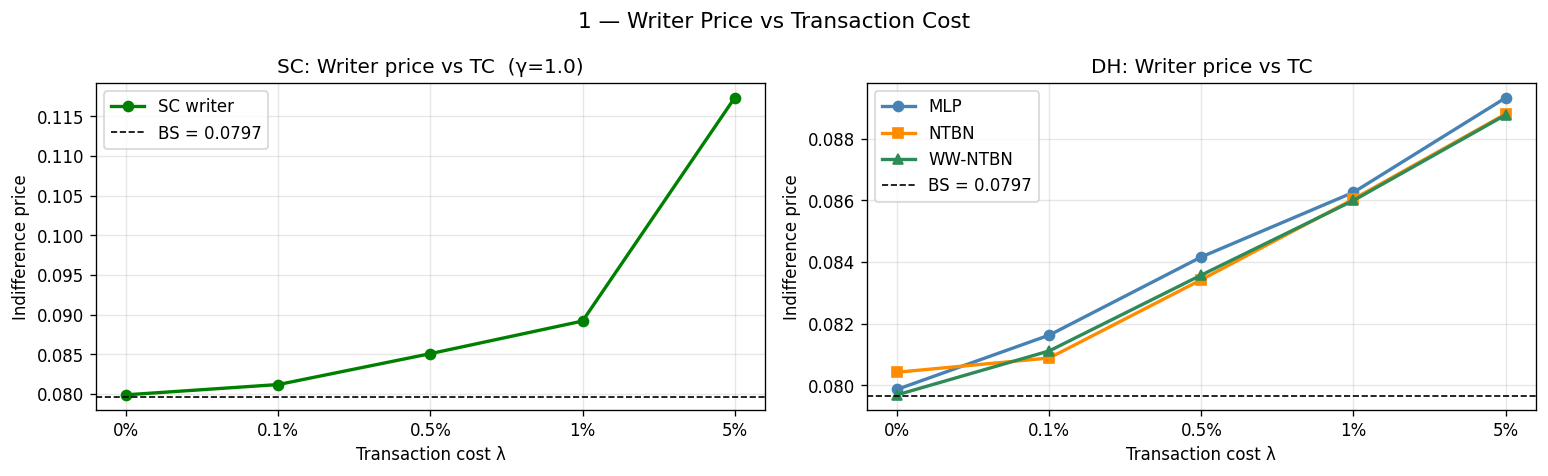

In [67]:
# SC writer prices
_pr = TC_pricer(opt_param, diff_param, cost_b=0.0, cost_s=0.0, gamma=gamma)
sc_writer = []
for tc in TC_LEVELS:
    _pr.cost_b = tc; _pr.cost_s = tc
    sc_writer.append(_pr.price(N=1000, TYPE="writer"))

# DH writer prices
n_eval = 10000
dh_price_MLP  = {i: hedgers_MLP[i].price(derivatives[i],  n_paths=n_eval, n_times=10).item() for i in tc_map}
dh_price_NTBN = {i: hedgers_NTBN[i].price(derivatives[i], n_paths=n_eval, n_times=10).item() for i in tc_map}
dh_price_WW   = {i: hedgers_WW[i].price(derivatives[i],   n_paths=n_eval, n_times=10).item() for i in tc_map}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x_pos, sc_writer, color=COL_SC, marker="o", linewidth=2, label="SC writer")
ax.axhline(bs_ref, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_ref:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("Transaction cost \u03bb"); ax.set_ylabel("Indifference price")
ax.set_title(f"SC: Writer price vs TC  (\u03b3={gamma})"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_pos, [dh_price_MLP[i]  for i in range(5)], color=COL_MLP,  marker="o", linewidth=2, label="MLP")
ax.plot(x_pos, [dh_price_NTBN[i] for i in range(5)], color=COL_NTBN, marker="s", linewidth=2, label="NTBN")
ax.plot(x_pos, [dh_price_WW[i]   for i in range(5)], color=COL_WW,   marker="^", linewidth=2, label="WW-NTBN")
ax.axhline(bs_ref, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_ref:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("Transaction cost \u03bb"); ax.set_ylabel("Indifference price")
ax.set_title("DH: Writer price vs TC"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("1 \u2014 Writer Price vs Transaction Cost", fontsize=13)
plt.tight_layout(); plt.show()


## 2 — TC=0 Price vs Black-Scholes


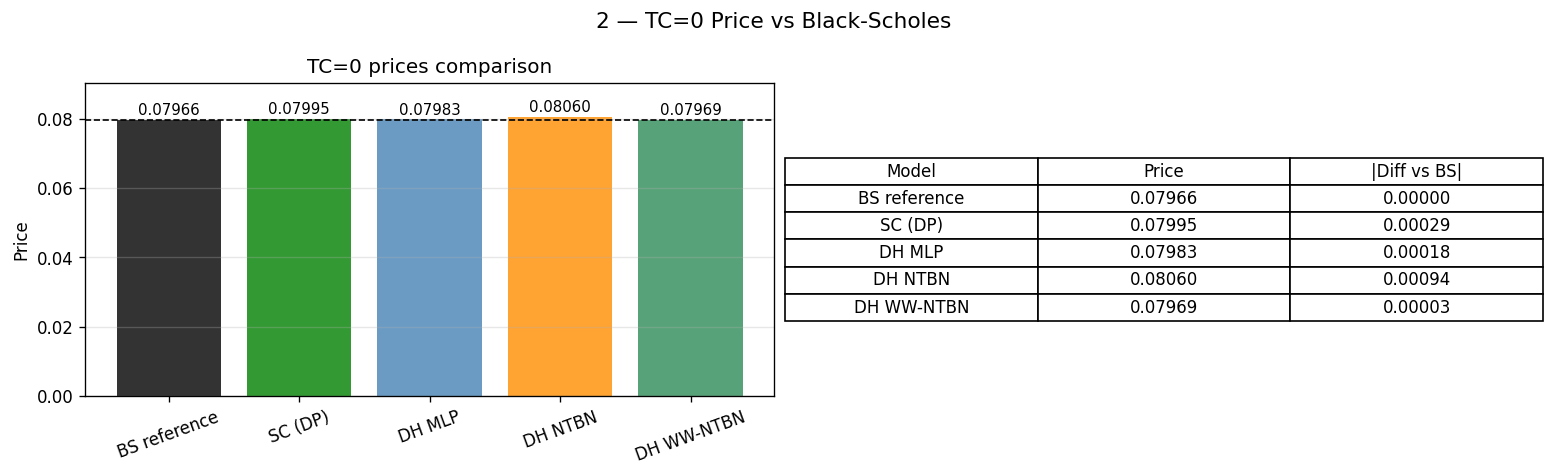

In [6]:
names  = ["BS reference", "SC (DP)", "DH MLP", "DH NTBN", "DH WW-NTBN"]
prices = [bs_ref, sc_writer[0], dh_price_MLP[0], dh_price_NTBN[0], dh_price_WW[0]]
colors = ["black", COL_SC, COL_MLP, COL_NTBN, COL_WW]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.bar(names, prices, color=colors, alpha=0.8)
ax.axhline(bs_ref, color="black", linestyle="--", linewidth=1)
for bar, p in zip(bars, prices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f"{p:.5f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Price"); ax.set_title("TC=0 prices comparison")
ax.set_ylim(0, max(prices) * 1.12)
ax.tick_params(axis="x", rotation=20); ax.grid(True, alpha=0.3, axis="y")

df2 = pd.DataFrame({
    "Model": names,
    "Price": [f"{p:.5f}" for p in prices],
    "|Diff vs BS|": [f"{abs(p - bs_ref):.5f}" for p in prices],
})
ax2 = axes[1]; ax2.axis("off")
tbl = ax2.table(cellText=df2.values, colLabels=df2.columns, cellLoc="center", loc="center")
tbl.auto_set_font_size(True); tbl.scale(1.1, 1.6)

plt.suptitle("2 \u2014 TC=0 Price vs Black-Scholes", fontsize=13)
plt.tight_layout(); plt.show()


## 3 — No-Transaction Band

Visualised at t=0.1 (ttm=0.9), TC=1% (γ=1).  
**SC**: upper/lower boundaries of the no-trade zone extracted from the DP action map.  
**DH**: band boundaries from the trained NTBN and WW-Guided NTBN.


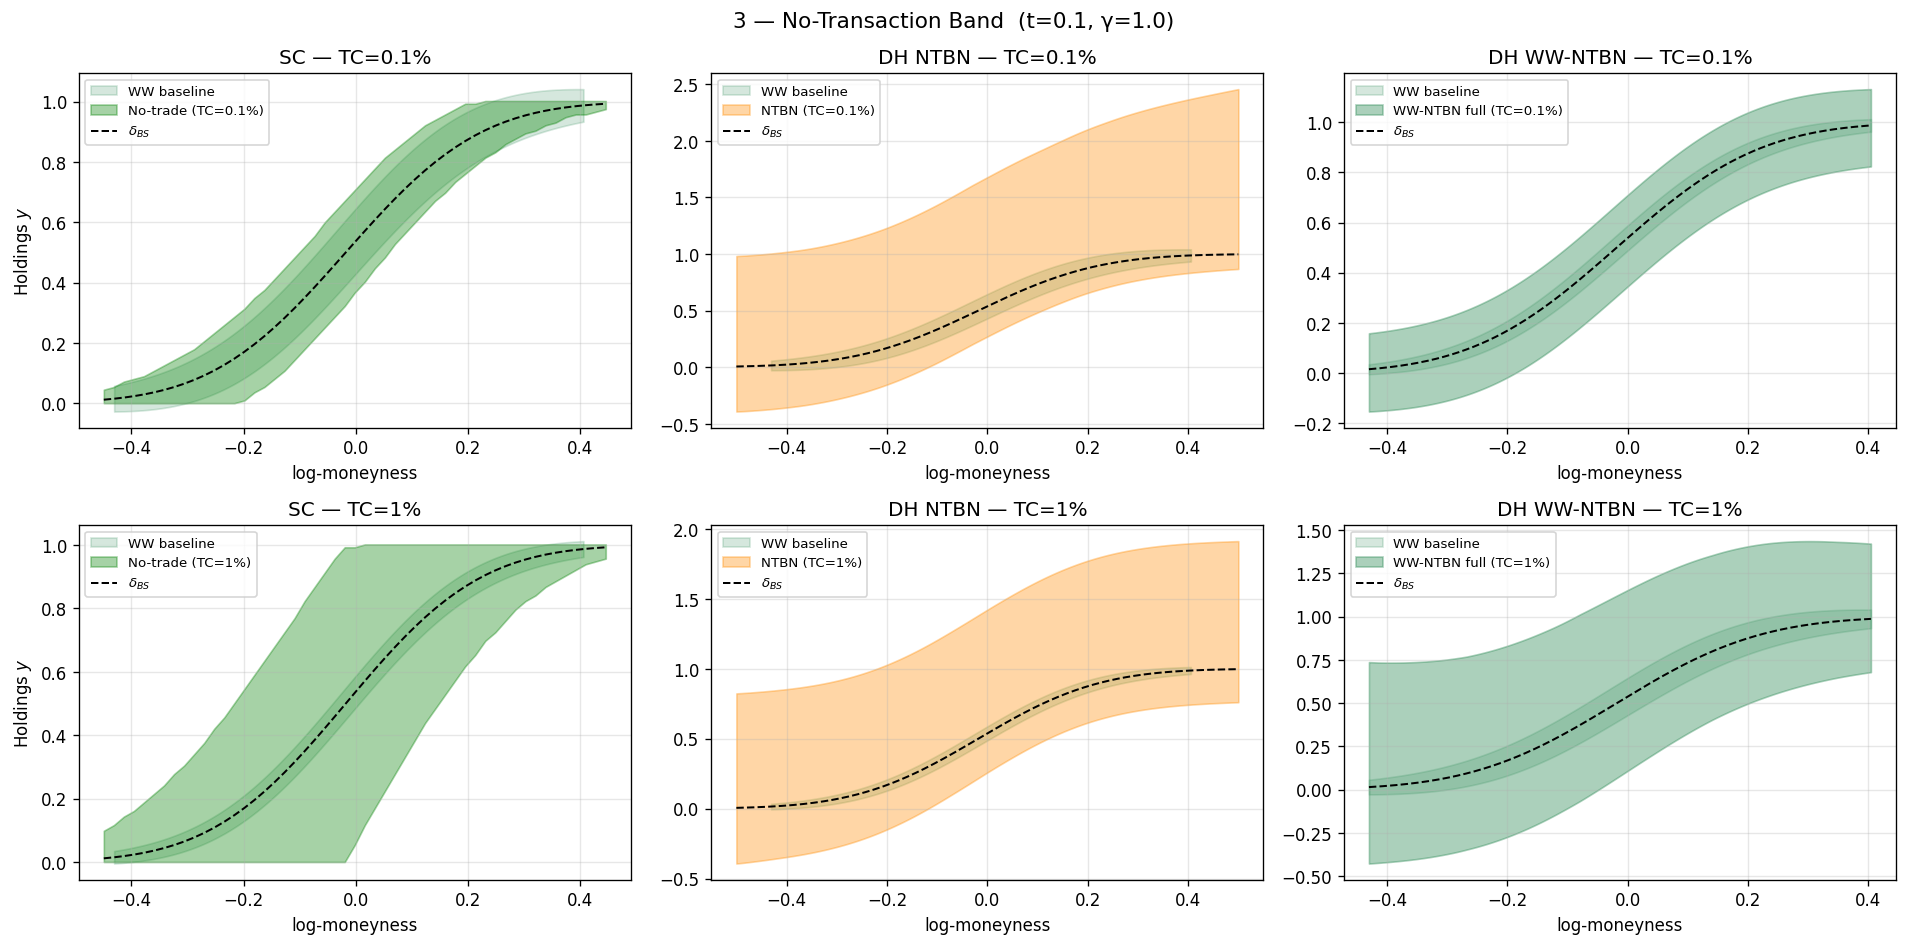

In [ ]:
# ── Helper: extract SC no-trade band boundaries ──────────────────────────
def sc_band_bounds(A_slice, y_grid):
    lo = np.empty(A_slice.shape[0])
    hi = np.empty(A_slice.shape[0])
    for j in range(A_slice.shape[0]):
        nt = np.nonzero(A_slice[j] == 0)[0]
        lo[j] = y_grid[nt[0]]  if len(nt) else y_grid[len(y_grid)//2]
        hi[j] = y_grid[nt[-1]] if len(nt) else y_grid[len(y_grid)//2]
    return lo, hi

# ── Common setup ──────────────────────────────────────────────────────────
t_plot   = 0.1
N_sc     = 500
k_sc     = int(round(t_plot / T * N_sc))
tc_pairs = [(1, "0.1%"), (3, "1%")]   # (tc_map index, label)

log_m_t  = torch.linspace(-0.5, 0.5, 600)
features_base = torch.stack([log_m_t,
                              torch.full_like(log_m_t, T - t_plot),
                              torch.full_like(log_m_t, sig)], dim=-1)
log_m_np = np.array(log_m_t.tolist())

# ── Plot: 2 rows × 3 cols ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (i_tc, tc_lbl) in enumerate(tc_pairs):

    # ── WW-NTBN band (computed first — used as background in all columns) ──
    with torch.no_grad():
        lm_ww, delta_ww_t, lo_ww, hi_ww, lo_ww_b, hi_ww_b = notransactionband_ww(
            K, T, t_plot, sig, hedgers_WW[i_tc].model)
        lm_ww_np    = np.array(lm_ww.tolist())
        delta_ww_np = np.array(delta_ww_t.tolist())
        lo_ww_np    = np.array(lo_ww.tolist())
        hi_ww_np    = np.array(hi_ww.tolist())
        lo_ww_b_np  = np.array(lo_ww_b.tolist())
        hi_ww_b_np  = np.array(hi_ww_b.tolist())

    # ── SC ────────────────────────────────────────────────────────────────
    TC_row = TC_pricer(opt_param, diff_param,
                       cost_b=TC_LEVELS[i_tc], cost_s=TC_LEVELS[i_tc], gamma=gamma)
    _, _, As_row, xg_row, yg_row = run_and_track(TC_row, N=N_sc, TYPE="writer")
    lm_row  = xg_row[k_sc] - np.log(K)
    lo_row, hi_row = sc_band_bounds(As_row[k_sc], yg_row)
    _, delta_sc, _ = compute_phi_w(xg_row[k_sc], K=K, r=r, mu=mu, sig=sig,
                                    T=T, t=t_plot, gamma=gamma)

    ax = axes[row, 0]
    ax.fill_between(lm_ww_np, lo_ww_b_np, hi_ww_b_np, alpha=0.20, color=COL_WW,
                    label="WW baseline")
    ax.fill_between(lm_row, lo_row, hi_row, alpha=0.35, color=COL_SC,
                    label=f"No-trade (TC={tc_lbl})")
    ax.plot(lm_row, delta_sc, "k--", linewidth=1.2, label=r"$\delta_{BS}$")
    ax.set_xlabel("log-moneyness"); ax.set_ylabel("Holdings $y$")
    ax.set_title(f"SC — TC={tc_lbl}"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── DH NTBN ───────────────────────────────────────────────────────────
    with torch.no_grad():
        m_ntbn   = hedgers_NTBN[i_tc].model
        delta_dh = m_ntbn.delta(features_base).squeeze(-1)
        out_n    = m_ntbn.mlp(features_base)
        lo_ntbn  = np.array((delta_dh - F.softplus(out_n[:, 0])).tolist())
        hi_ntbn  = np.array((delta_dh + F.softplus(out_n[:, 1])).tolist())
        delta_np = np.array(delta_dh.tolist())

    ax = axes[row, 1]
    ax.fill_between(lm_ww_np, lo_ww_b_np, hi_ww_b_np, alpha=0.20, color=COL_WW,
                    label="WW baseline")
    ax.fill_between(log_m_np, lo_ntbn, hi_ntbn, alpha=0.35, color=COL_NTBN,
                    label=f"NTBN (TC={tc_lbl})")
    ax.plot(log_m_np, delta_np, "k--", linewidth=1.2, label=r"$\delta_{BS}$")
    ax.set_xlabel("log-moneyness"); ax.set_ylabel("")
    ax.set_title(f"DH NTBN — TC={tc_lbl}"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── DH WW-NTBN ────────────────────────────────────────────────────────
    ax = axes[row, 2]
    ax.fill_between(lm_ww_np, lo_ww_b_np, hi_ww_b_np, alpha=0.20, color=COL_WW,
                    label="WW baseline")
    ax.fill_between(lm_ww_np, lo_ww_np, hi_ww_np,     alpha=0.40, color=COL_WW,
                    label=f"WW-NTBN full (TC={tc_lbl})")
    ax.plot(lm_ww_np, delta_ww_np, "k--", linewidth=1.2, label=r"$\delta_{BS}$")
    ax.set_xlabel("log-moneyness"); ax.set_ylabel("")
    ax.set_title(f"DH WW-NTBN — TC={tc_lbl}"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f"3 \u2014 No-Transaction Band  (t={t_plot}, \u03b3={gamma})", fontsize=13)
plt.tight_layout(); plt.show()

## 4 — Terminal P&L Distributions

Comparing SC (using DP policy + Monte-Carlo simulation via `simulate_pnl`) and DH
(all three models) at TC=0.5% and TC=5%.  
Vertical lines: solid = mean, dashed = CVaR 95%.


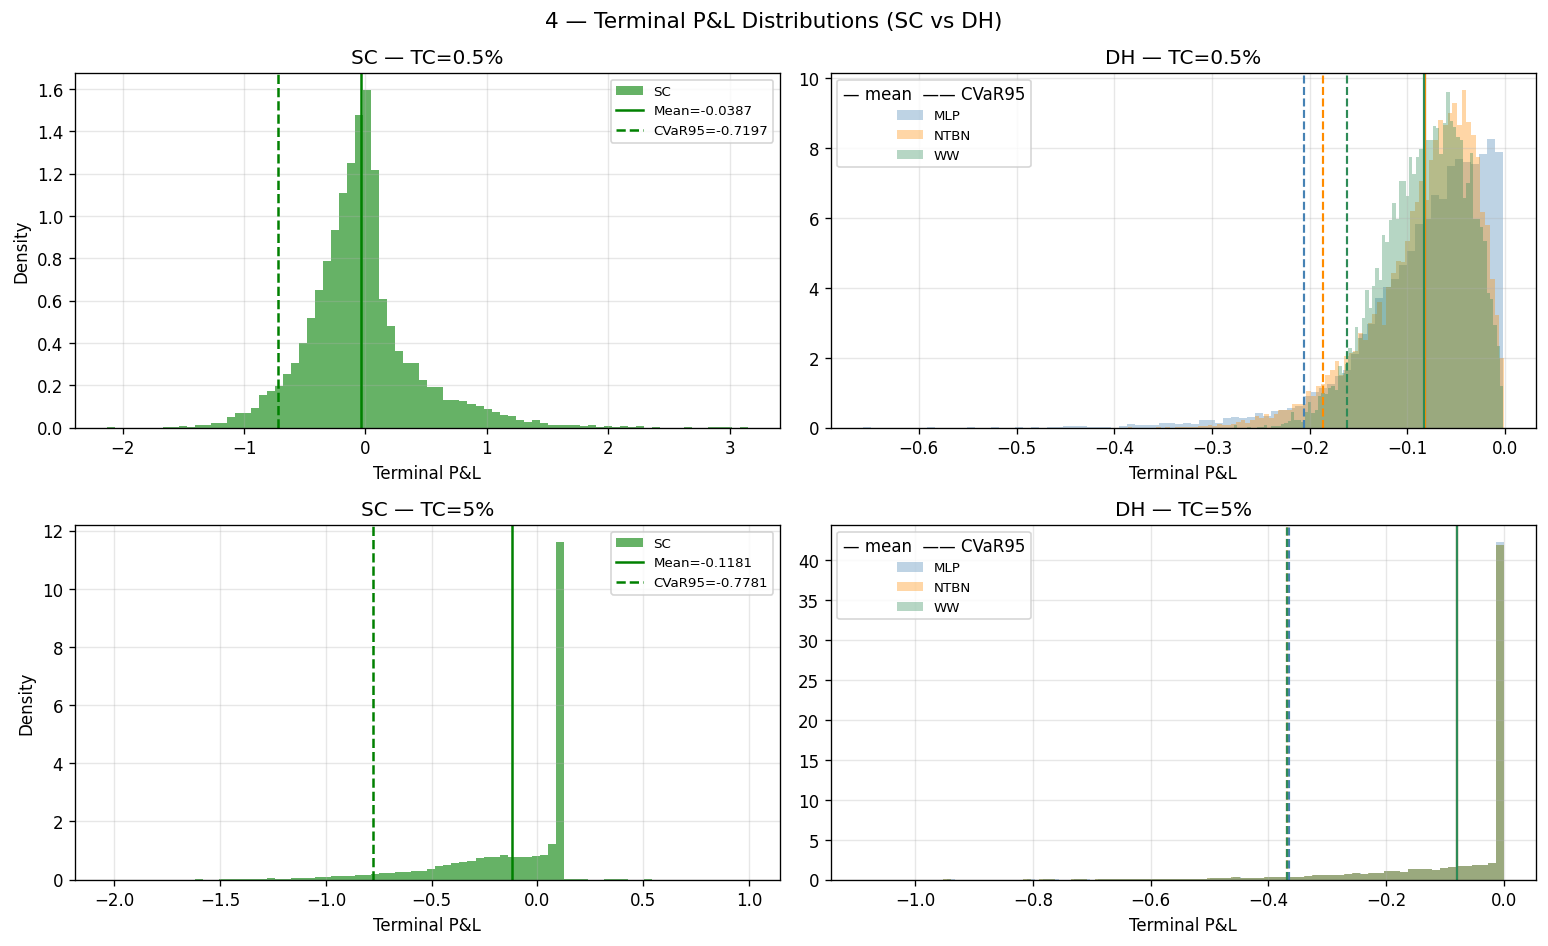

In [68]:
pnl_idx  = [2, 4]   # TC=0.5%, TC=5%
N_sim_sc = 10000
N_sim_dh = 10000

# ── SC P&L ────────────────────────────────────────────────────────────────
sc_pnl = {}
for idx in pnl_idx:
    tc = TC_LEVELS[idx]
    pr = TC_pricer(opt_param, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    price_w, _, As_pnl, _, _ = run_and_track(pr, N=1000, TYPE="writer")
    raw = simulate_pnl(As_pnl, pr,
                       payoff_func=lambda S_T: np.maximum(S_T - K, 0.0),
                       M_paths=N_sim_sc, seed=42)
    sc_pnl[idx] = price_w + raw   # writer P&L = premium + hedging cash flows - payoff

# ── DH P&L ────────────────────────────────────────────────────────────────
dh_pnl = {}
for idx in pnl_idx:
    derivatives[idx].simulate(n_paths=N_sim_dh)
    dh_pnl[idx] = {
        "MLP":  hedgers_MLP[idx].compute_pl(derivatives[idx]).detach(),
        "NTBN": hedgers_NTBN[idx].compute_pl(derivatives[idx]).detach(),
        "WW":   hedgers_WW[idx].compute_pl(derivatives[idx]).detach(),
    }

# ── Plot ─────────────────────────────────────────────────────────────────
dh_colors = {"MLP": COL_MLP, "NTBN": COL_NTBN, "WW": COL_WW}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, idx in enumerate(pnl_idx):
    tc_label = TC_LABELS[idx]

    # SC
    ax = axes[row, 0]
    arr = sc_pnl[idx]
    cvar = np.percentile(arr, 5)
    ax.hist(arr, bins=80, density=True, color=COL_SC, alpha=0.6, label="SC")
    ax.axvline(arr.mean(), color=COL_SC, linestyle="-",  linewidth=1.5, label=f"Mean={arr.mean():+.4f}")
    ax.axvline(cvar,       color=COL_SC, linestyle="--", linewidth=1.5, label=f"CVaR95={cvar:+.4f}")
    ax.set_title(f"SC \u2014 TC={tc_label}"); ax.legend(fontsize=8)
    ax.set_xlabel("Terminal P&L"); ax.set_ylabel("Density"); ax.grid(True, alpha=0.3)

    # DH (all models overlaid)
    ax = axes[row, 1]
    for name, pnl in dh_pnl[idx].items():
        arr = np.array(pnl.tolist())
        cvar = np.percentile(arr, 5)
        c = dh_colors[name]
        ax.hist(arr, bins=80, alpha=0.35, density=True, color=c, label=name)
        ax.axvline(arr.mean(), color=c, linestyle="-",  linewidth=1.3)
        ax.axvline(cvar,       color=c, linestyle="--", linewidth=1.3)
    ax.set_title(f"DH \u2014 TC={tc_label}")
    ax.set_xlabel("Terminal P&L"); ax.legend(fontsize=8, title="\u2014 mean  \u2014\u2014 CVaR95")
    ax.grid(True, alpha=0.3)

plt.suptitle("4 \u2014 Terminal P&L Distributions (SC vs DH)", fontsize=13)
plt.tight_layout(); plt.show()


## 5 — Trade Metrics vs Transaction Cost


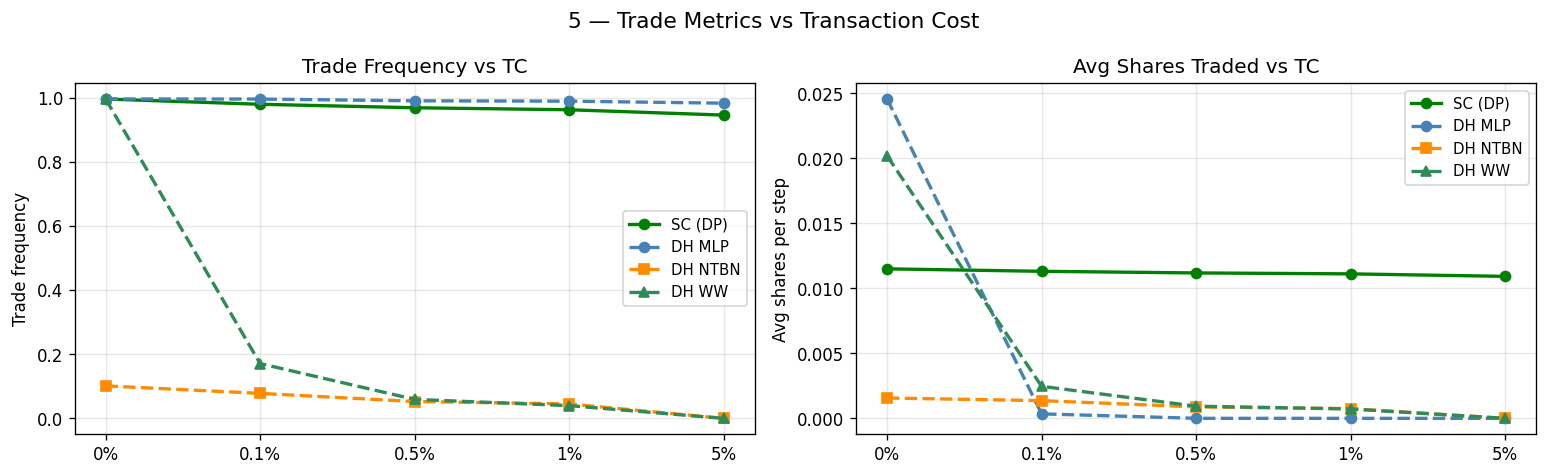

In [9]:
# ── SC trade metrics ─────────────────────────────────────────────────────
sc_freq, sc_shares = [], []
_pr_m = TC_pricer(opt_param, diff_param, cost_b=0.0, cost_s=0.0, gamma=gamma)
for tc in TC_LEVELS:
    _pr_m.cost_b = tc; _pr_m.cost_s = tc
    _, _, As_m, _, yg_m = run_and_track(_pr_m, N=300, TYPE="writer")
    dy_m = yg_m[1] - yg_m[0]
    sc_freq.append(compute_trade_frequency(As_m))
    sc_shares.append(compute_num_shares(As_m, dy_m))

# ── DH trade metrics ──────────────────────────────────────────────────────
n_tm = 5000
dh_freq   = {"MLP": [], "NTBN": [], "WW": []}
dh_shares = {"MLP": [], "NTBN": [], "WW": []}

for i in range(5):
    derivatives[i].simulate(n_paths=n_tm)
    h_mlp  = hedgers_MLP[i].compute_hedge(derivatives[i]).squeeze(1)
    h_ntbn = hedgers_NTBN[i].compute_hedge(derivatives[i]).squeeze(1)
    h_ww   = hedgers_WW[i].compute_hedge(derivatives[i]).squeeze(1)
    for name, h in [("MLP", h_mlp), ("NTBN", h_ntbn), ("WW", h_ww)]:
        dh_freq[name].append(compute_trade_frequency_pfhedge(h))
        dh_shares[name].append(compute_avg_num_shares_traded_pfhedge(h))

# ── Plot ─────────────────────────────────────────────────────────────────
dh_colors = {"MLP": COL_MLP, "NTBN": COL_NTBN, "WW": COL_WW}
dh_markers = {"MLP": "o", "NTBN": "s", "WW": "^"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(x_pos, sc_freq, color=COL_SC, marker="o", linewidth=2, label="SC (DP)")
for name in ["MLP", "NTBN", "WW"]:
    ax.plot(x_pos, dh_freq[name], color=dh_colors[name], marker=dh_markers[name],
            linewidth=2, linestyle="--", label=f"DH {name}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_ylabel("Trade frequency"); ax.set_title("Trade Frequency vs TC")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_pos, sc_shares, color=COL_SC, marker="o", linewidth=2, label="SC (DP)")
for name in ["MLP", "NTBN", "WW"]:
    ax.plot(x_pos, dh_shares[name], color=dh_colors[name], marker=dh_markers[name],
            linewidth=2, linestyle="--", label=f"DH {name}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_ylabel("Avg shares per step"); ax.set_title("Avg Shares Traded vs TC")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("5 \u2014 Trade Metrics vs Transaction Cost", fontsize=13)
plt.tight_layout(); plt.show()


## 6 — Writer & Buyer Indifference Prices vs TC


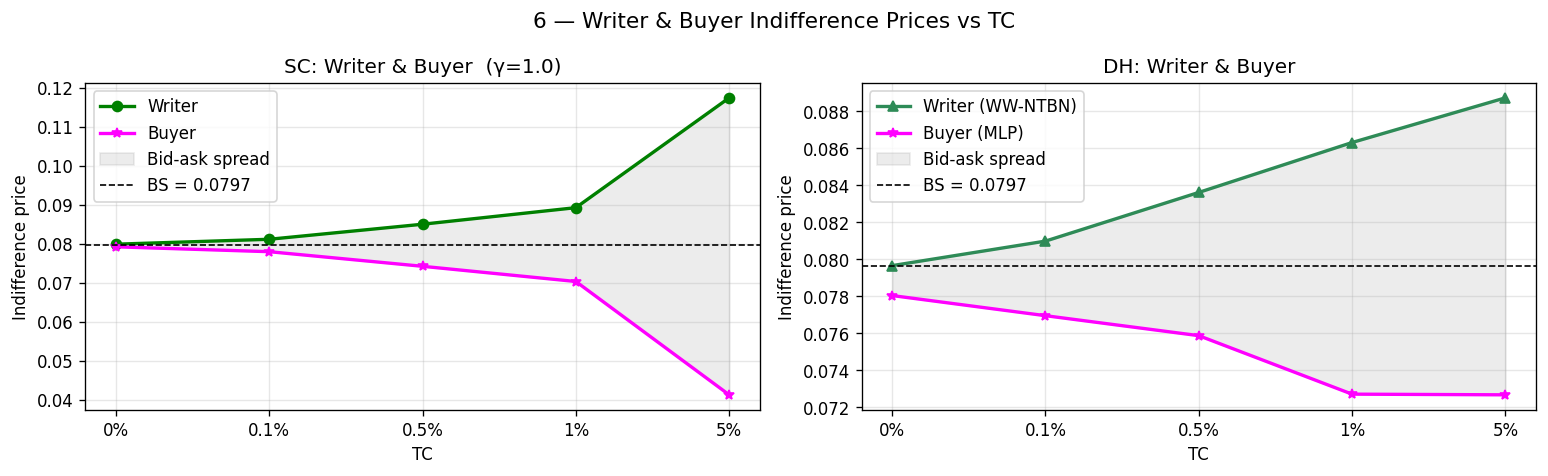

In [10]:
# ── SC writer & buyer ────────────────────────────────────────────────────
sc_w, sc_b = [], []
_pr_wb = TC_pricer(opt_param, diff_param, cost_b=0.0, cost_s=0.0, gamma=gamma)
for tc in TC_LEVELS:
    _pr_wb.cost_b = tc; _pr_wb.cost_s = tc
    sc_w.append(_pr_wb.price(N=400, TYPE="writer"))
    sc_b.append(_pr_wb.price(N=400, TYPE="buyer"))

# ── DH writer (WW-NTBN) & buyer (MLP) ────────────────────────────────────
dh_writer = [hedgers_WW[i].price(derivatives[i], n_paths=n_eval, n_times=10).item()
             for i in range(5)]
dh_buyer  = [-buyer_hedgers[i].price(buyer_derivatives[i], n_paths=n_eval).item()
             for i in range(5)]

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x_pos, sc_w, marker="o", linewidth=2, color=COL_SC,    label="Writer")
ax.plot(x_pos, sc_b, marker="*", linewidth=2, color=COL_BUYER, label="Buyer")
ax.fill_between(x_pos, sc_b, sc_w, alpha=0.15, color="gray", label="Bid-ask spread")
ax.axhline(bs_ref, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_ref:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("TC"); ax.set_ylabel("Indifference price")
ax.set_title(f"SC: Writer & Buyer  (\u03b3={gamma})"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_pos, dh_writer, marker="^", linewidth=2, color=COL_WW,    label="Writer (WW-NTBN)")
ax.plot(x_pos, dh_buyer,  marker="*", linewidth=2, color=COL_BUYER, label="Buyer (MLP)")
ax.fill_between(x_pos, dh_buyer, dh_writer, alpha=0.15, color="gray", label="Bid-ask spread")
ax.axhline(bs_ref, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_ref:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("TC"); ax.set_ylabel("Indifference price")
ax.set_title("DH: Writer & Buyer"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("6 \u2014 Writer & Buyer Indifference Prices vs TC", fontsize=13)
plt.tight_layout(); plt.show()


## 7 — DH Training Loss History


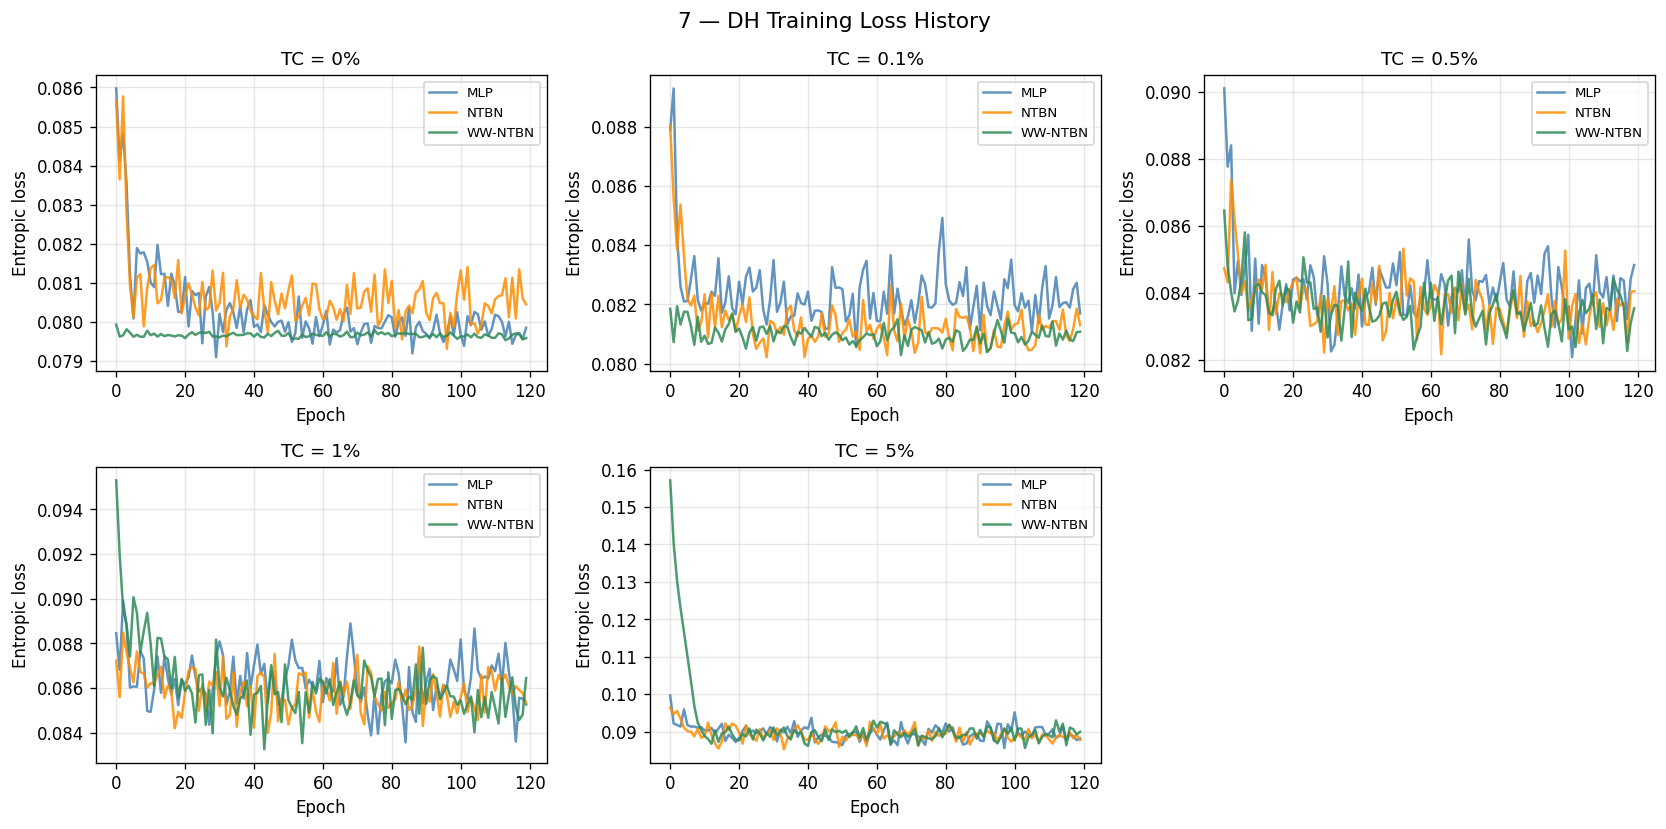

In [11]:
if loss_hist_MLP and loss_hist_NTBN and loss_hist_WW:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes_flat = axes.flatten()
    for idx, i in enumerate(tc_map):
        ax = axes_flat[idx]
        ax.plot(loss_hist_MLP[i],  label="MLP",     color=COL_MLP,  alpha=0.85)
        ax.plot(loss_hist_NTBN[i], label="NTBN",    color=COL_NTBN, alpha=0.85)
        ax.plot(loss_hist_WW[i],   label="WW-NTBN", color=COL_WW,   alpha=0.85)
        ax.set_title(f"TC = {TC_LABELS[i]}", fontsize=11)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Entropic loss")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    axes_flat[-1].set_visible(False)
    plt.suptitle("7 \u2014 DH Training Loss History", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("Loss history not available. Set train=True in the DH notebook and retrain.")


## 8 — Call Spread Prices vs TC  (K₁=0.9, K₂=1.1)

**Joint**: single hedger for the full call spread payoff max(S-K₁,0)−max(S-K₂,0).  
**Naïve**: separate hedger per leg, costs added independently.


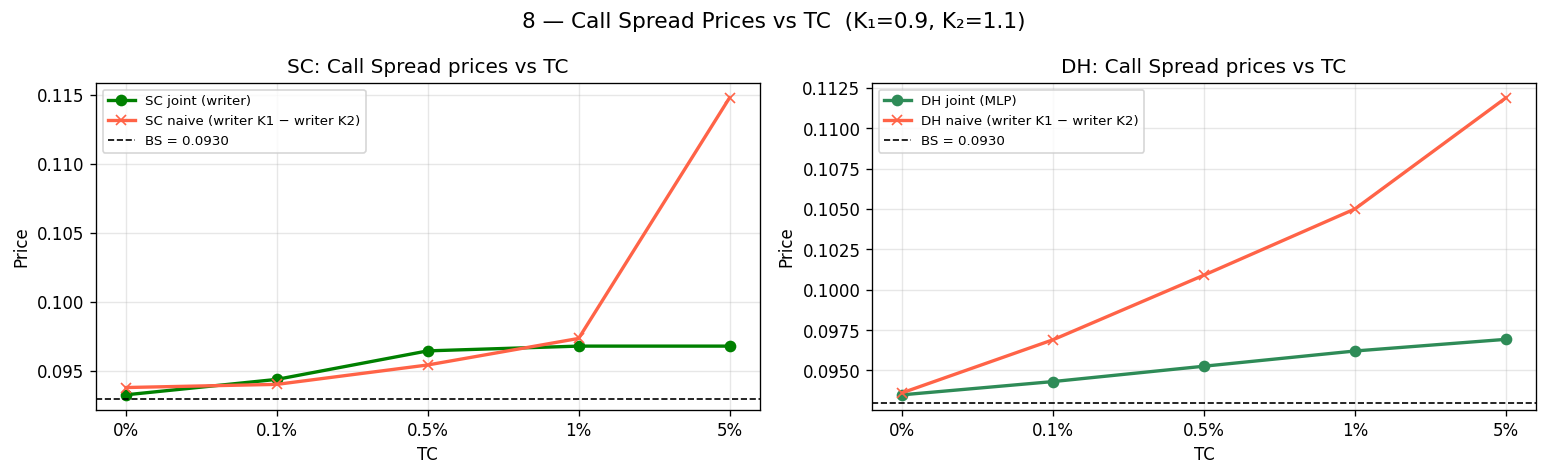

In [42]:
# BS reference for the spread
BS_K1 = BS_pricer(Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call"), diff_param)
BS_K2 = BS_pricer(Option_param(S0=S0, K=K2, T=T, exercise="European", payoff="call"), diff_param)
bs_spread = BS_K1.closed_formula() - BS_K2.closed_formula()

# ── SC call spread prices ─────────────────────────────────────────────────
opt_cs1 = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")
opt_cs2 = Option_param(S0=S0, K=K2, T=T, exercise="European", payoff="call")
opt_csi = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")

sc_cs_joint = []
sc_cs_naive = []

for tc in TC_LEVELS:
    pr_cs = TC_pricer_CS(opt_csi, diff_param, K1, K2, cost_b=tc, cost_s=tc, gamma=gamma)
    sc_cs_joint.append(pr_cs.price(N=300, TYPE="callspread_writer"))
    pr1 = TCP(opt_cs1, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    pr2 = TCP(opt_cs2, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    sc_cs_naive.append(pr1.price(N=300, TYPE="writer") - pr2.price(N=300, TYPE="writer"))

# ── DH call spread prices ─────────────────────────────────────────────────
dh_cs_joint  = [hedgers_cs[i].price(derivatives_cs[i], n_paths=n_eval, n_times=10).item()
                for i in range(5)]
dh_K1_prices = [ hedgers_K1[i].price(derivatives_K1[i], n_paths=n_eval, n_times=10).item()
                 for i in range(5)]
dh_K2_prices = [-hedgers_K2[i].price(derivatives_K2[i], n_paths=n_eval, n_times=10).item()
                 for i in range(5)]
dh_cs_naive  = [dh_K1_prices[i] - dh_K2_prices[i] for i in range(5)]

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x_pos, sc_cs_joint, marker="o", linewidth=2, color=COL_SC,    label="SC joint (writer)")
ax.plot(x_pos, sc_cs_naive, marker="x", linewidth=2, color=COL_NAIVE, label="SC naive (writer K1 \u2212 writer K2)")
ax.axhline(bs_spread, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_spread:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("TC"); ax.set_ylabel("Price"); ax.set_title("SC: Call Spread prices vs TC")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_pos, dh_cs_joint, marker="o", linewidth=2, color=COL_WW,    label="DH joint (MLP)")
ax.plot(x_pos, dh_cs_naive, marker="x", linewidth=2, color=COL_NAIVE, label="DH naive (writer K1 \u2212 writer K2)")
ax.axhline(bs_spread, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_spread:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("TC"); ax.set_ylabel("Price"); ax.set_title("DH: Call Spread prices vs TC")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f"8 \u2014 Call Spread Prices vs TC  (K\u2081={K1}, K\u2082={K2})", fontsize=13)
plt.tight_layout(); plt.show()


## 9 — Call Spread No-Transaction Band  (SC only)

The no-trade region for the joint call spread hedger at t=0.1.  
Light band = TC=0%, dark band = TC=1%. Dashed line = BS delta of the spread.


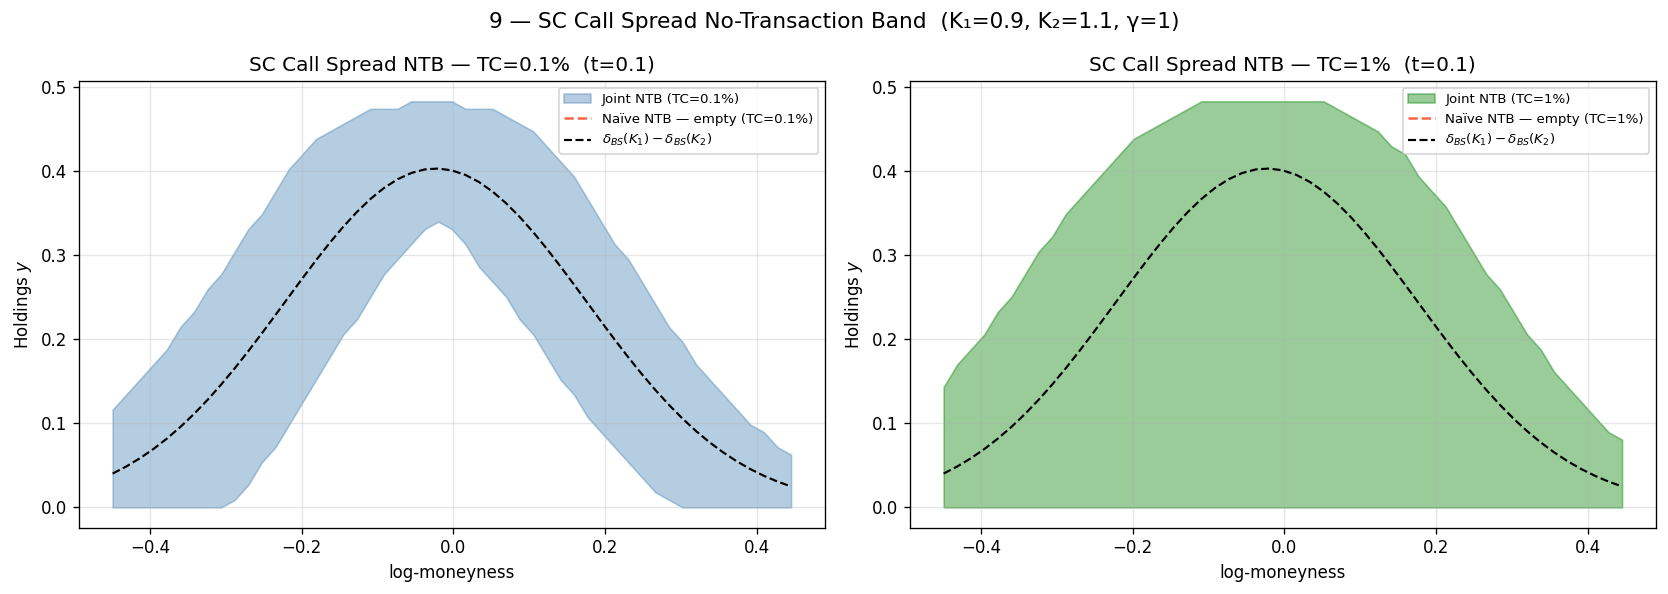

In [63]:
opt_cs_nb  = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")
opt_c1_nb  = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")
opt_c2_nb  = Option_param(S0=S0, K=K2, T=T, exercise="European", payoff="call")
i_tc_lo    = 1    # TC = 0.1%
i_tc_hi    = 3    # TC = 1%

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, i_tc, tc_lbl, col_joint in [
    (axes[0], i_tc_lo, "0.1%", "steelblue"),
    (axes[1], i_tc_hi, "1%",   COL_SC),
]:
    tc = TC_LEVELS[i_tc]

    # ── Joint NTB ─────────────────────────────────────────────────────────
    TC_CS = TC_pricer_CS(opt_cs_nb, diff_param, K1, K2, cost_b=tc, cost_s=tc, gamma=gamma)
    _, _, As_cs, xg_cs, yg_cs = run_and_track(TC_CS, N=N_sc, TYPE="callspread_writer")
    lm_cs = xg_cs[k_sc] - np.log(K)
    lo_cs, hi_cs = sc_band_bounds(As_cs[k_sc], yg_cs)

    # ── Individual writer bands ────────────────────────────────────────────
    pr_c1 = TC_pricer(opt_c1_nb, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    pr_c2 = TC_pricer(opt_c2_nb, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    _, _, As_c1, xg_c1, yg_c1 = run_and_track(pr_c1, N=N_sc, TYPE="writer")
    _, _, As_c2, xg_c2, yg_c2 = run_and_track(pr_c2, N=N_sc, TYPE="buyer")
    lm_c1 = xg_c1[k_sc] - np.log(K)
    lo_c1, hi_c1 = sc_band_bounds(As_c1[k_sc], yg_c1)
    lo_c2, hi_c2 = sc_band_bounds(As_c2[k_sc], yg_c2)

    # Align K2 band onto K1 x-grid (grids are identical in practice)
    lo_c2_i = np.interp(lm_c1, lm_c1, lo_c2[:len(lm_c1)])
    hi_c2_i = np.interp(lm_c1, lm_c1, hi_c2[:len(lm_c1)])

    # Naive NTB = intersection: region where y lies inside BOTH individual bands
    lo_naive = np.maximum(lo_c1, lo_c2_i)
    hi_naive = np.minimum(hi_c1, hi_c2_i)
    # Mask to only fill where the intersection is non-empty
    valid = hi_naive > lo_naive

    # ── BS delta of the spread ─────────────────────────────────────────────
    S_cs   = np.exp(xg_cs[k_sc])
    tau_cs = T - t_plot
    d1_K1  = (np.log(S_cs/K1) + 0.5*sig**2*tau_cs) / (sig*np.sqrt(tau_cs))
    d1_K2  = (np.log(S_cs/K2) + 0.5*sig**2*tau_cs) / (sig*np.sqrt(tau_cs))
    delta_cs_bs = _norm.cdf(d1_K1) - _norm.cdf(d1_K2)

    # ── Plot ──────────────────────────────────────────────────────────────
    ax.fill_between(lm_cs,  lo_cs,  hi_cs,  alpha=0.40, color=col_joint,
                    label=f"Joint NTB (TC={tc_lbl})")
    if valid.any():
        ax.fill_between(lm_c1[valid], lo_naive[valid], hi_naive[valid],
                        alpha=0.45, color=COL_NAIVE, label=f"Naïve NTB — intersection (TC={tc_lbl})")
        ax.plot(lm_c1[valid], lo_naive[valid], color=COL_NAIVE, linewidth=1.0, linestyle="--")
        ax.plot(lm_c1[valid], hi_naive[valid], color=COL_NAIVE, linewidth=1.0, linestyle="--")
    else:
        ax.axhline(np.nan, color=COL_NAIVE, linestyle="--",
                   label=f"Naïve NTB — empty (TC={tc_lbl})")
    ax.plot(lm_cs, delta_cs_bs, "k--", linewidth=1.3,
            label=r"$\delta_{BS}(K_1) - \delta_{BS}(K_2)$")
    ax.set_xlabel("log-moneyness"); ax.set_ylabel("Holdings $y$")
    ax.set_title(f"SC Call Spread NTB — TC={tc_lbl}  (t={t_plot})")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# shared y-axis
y_min = min(ax.get_ylim()[0] for ax in axes)
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(y_min, y_max)

plt.suptitle(f"9 \u2014 SC Call Spread No-Transaction Band  (K\u2081={K1}, K\u2082={K2}, \u03b3={gamma})",
             fontsize=13)
plt.tight_layout(); plt.show()

## 10 — Call Spread P&L and Scatter  (SC, TC=0.5%)

**Joint**: DP policy on `TC_pricer_CS` (writer perspective, γ=1).  
**Naïve**: writer-of-K₁ + writer-of-K₂ policies run independently, premiums added.

/var/folders/3_/t8l3yh8s28z9_jbq7gqy7byr0000gn/T/ipykernel_40232/1351688161.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


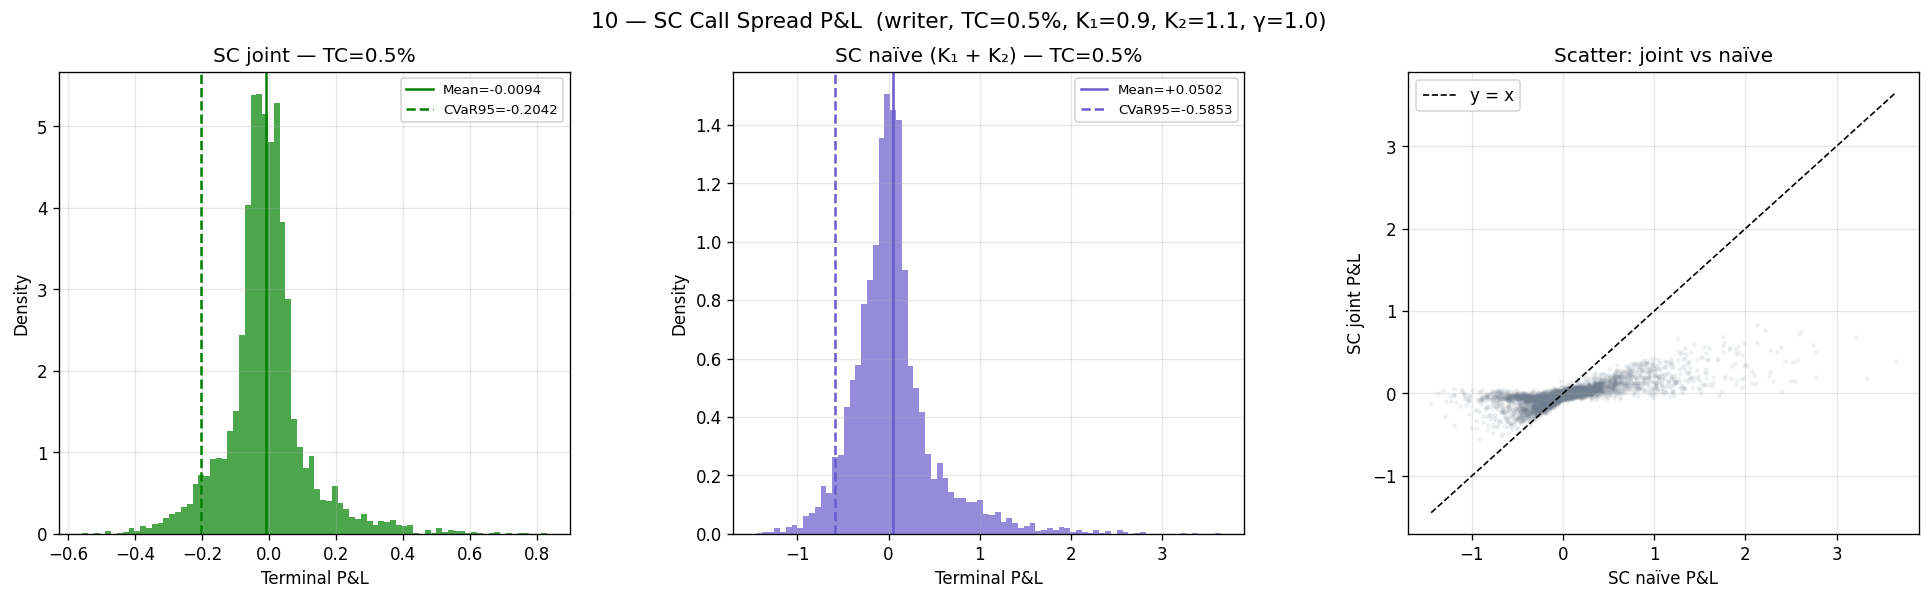

In [69]:
import matplotlib.gridspec as gridspec

i_cs_pnl  = 2       # TC = 0.5%
c_cs_pnl  = tc_cs[i_cs_pnl]
N_sim_cs  = 5000

# ── SC joint ──────────────────────────────────────────────────────────────
opt_cs_p = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")
pr_cs_p  = TC_pricer_CS(opt_cs_p, diff_param, K1, K2,
                         cost_b=c_cs_pnl, cost_s=c_cs_pnl, gamma=gamma)
price_cs_w, _, As_cs_p, _, _ = run_and_track(pr_cs_p, N=250, TYPE="callspread_writer")
arr_sc_joint = price_cs_w + simulate_pnl(
    As_cs_p, pr_cs_p,
    payoff_func=lambda S_T: np.maximum(S_T - K1, 0.0) - np.maximum(S_T - K2, 0.0),
    M_paths=N_sim_cs, seed=42)

# ── SC naive (writer K1 + writer K2) ─────────────────────────────────────
opt_c1 = Option_param(S0=S0, K=K1, T=T, payoff="call")
opt_c2 = Option_param(S0=S0, K=K2, T=T, payoff="call")
pr_c1 = TC_pricer(opt_c1, diff_param, cost_b=c_cs_pnl, cost_s=c_cs_pnl, gamma=gamma)
pr_c2 = TCP(opt_c2,       diff_param, cost_b=c_cs_pnl, cost_s=c_cs_pnl, gamma=gamma)
_ = pr_c1.price(N=250, TYPE="writer", track_policy=True)
_ = pr_c2.price(N=250, TYPE="writer", track_policy=True)
price_c1_w = pr_c1.price(N=250, TYPE="writer")
price_c2_w = pr_c2.price(N=250, TYPE="writer")
pnl_c1 = price_c1_w + simulate_pnl(
    pr_c1.action_slices["writer"], pr_c1,
    payoff_func=lambda S_T:  np.maximum(S_T - K1, 0.0), M_paths=N_sim_cs, seed=42)
pnl_c2 = price_c2_w + simulate_pnl(
    pr_c2.action_slices["writer"], pr_c2,
    payoff_func=lambda S_T: -np.maximum(S_T - K2, 0.0), M_paths=N_sim_cs, seed=42)
arr_sc_naive = pnl_c1 + pnl_c2

# ── Plot ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)
ax_j = fig.add_subplot(gs[0])
ax_n = fig.add_subplot(gs[1])
ax_s = fig.add_subplot(gs[2])

for ax, arr, color, title in [
    (ax_j, arr_sc_joint, COL_SC,      "SC joint"),
    (ax_n, arr_sc_naive, "slateblue", "SC naïve (K₁ + K₂)"),
]:
    cvar = np.percentile(arr, 5)
    ax.hist(arr, bins=80, density=True, color=color, alpha=0.7)
    ax.axvline(arr.mean(), color=color, linestyle="-",  linewidth=1.5, label=f"Mean={arr.mean():+.4f}")
    ax.axvline(cvar,       color=color, linestyle="--", linewidth=1.5, label=f"CVaR95={cvar:+.4f}")
    ax.set_title(f"{title} — TC=0.5%"); ax.legend(fontsize=8)
    ax.set_xlabel("Terminal P&L"); ax.set_ylabel("Density"); ax.grid(True, alpha=0.3)

mn = min(arr_sc_joint.min(), arr_sc_naive.min())
mx = max(arr_sc_joint.max(), arr_sc_naive.max())
ax_s.scatter(arr_sc_naive, arr_sc_joint, alpha=0.07, s=4, color="slategray")
ax_s.plot([mn, mx], [mn, mx], "k--", linewidth=1, label="y = x")
ax_s.set_xlabel("SC naïve P&L"); ax_s.set_ylabel("SC joint P&L")
ax_s.set_title("Scatter: joint vs naïve"); ax_s.legend(); ax_s.grid(True, alpha=0.3)

plt.suptitle(f"10 — SC Call Spread P&L  (writer, TC=0.5%, K₁={K1}, K₂={K2}, γ={gamma})",
             fontsize=13)
plt.tight_layout(); plt.show()

## 11 — Call Spread Trade Metrics vs TC


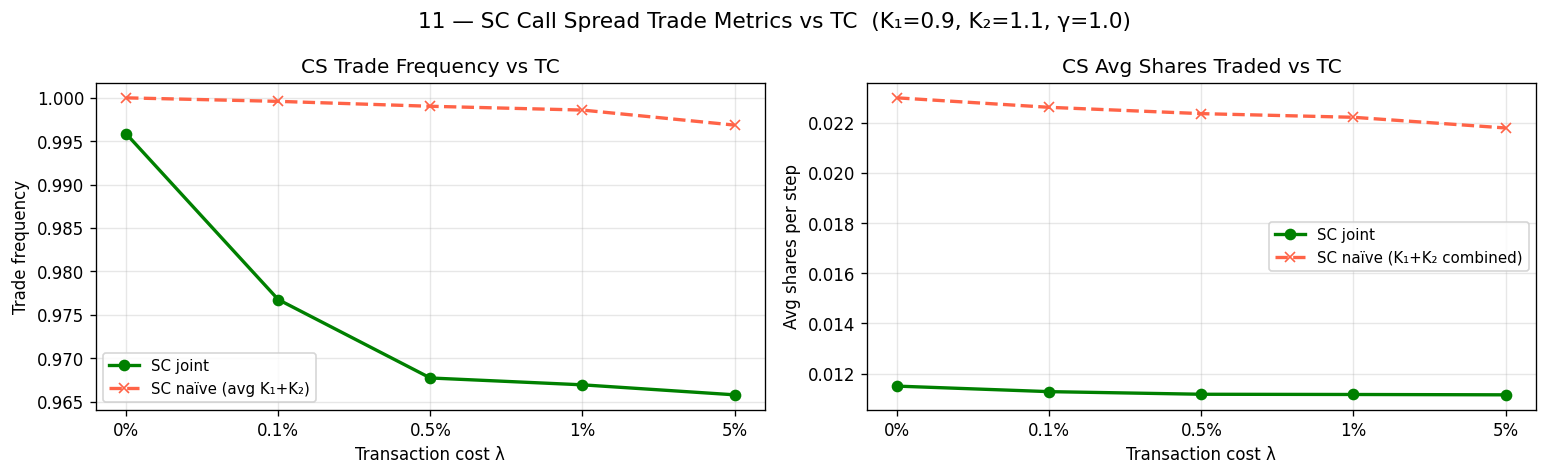

In [47]:
# ── SC joint: callspread_writer policy ───────────────────────────────────
sc_cs_freq_joint, sc_cs_shares_joint = [], []
opt_cs_m = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")
for tc in TC_LEVELS:
    pr_cs_m = TC_pricer_CS(opt_cs_m, diff_param, K1, K2, cost_b=tc, cost_s=tc, gamma=gamma)
    _, _, As_cs_m, _, yg_cs_m = run_and_track(pr_cs_m, N=300, TYPE="callspread_writer")
    dy_cs_m = yg_cs_m[1] - yg_cs_m[0]
    sc_cs_freq_joint.append(compute_trade_frequency(As_cs_m))
    sc_cs_shares_joint.append(compute_num_shares(As_cs_m, dy_cs_m))

# ── SC naive: writer K1 + writer K2 independently ─────────────────────────
sc_cs_freq_naive, sc_cs_shares_naive = [], []
opt_c1_m = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")
opt_c2_m = Option_param(S0=S0, K=K2, T=T, exercise="European", payoff="call")
for tc in TC_LEVELS:
    pr1_m = TC_pricer(opt_c1_m, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    pr2_m = TC_pricer(opt_c2_m, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    _, _, As1_m, _, yg1_m = run_and_track(pr1_m, N=300, TYPE="writer")
    _, _, As2_m, _, yg2_m = run_and_track(pr2_m, N=300, TYPE="buyer")
    dy1 = yg1_m[1] - yg1_m[0]
    dy2 = yg2_m[1] - yg2_m[0]
    # naive totals: sum frequency and shares across both legs
    freq1 = compute_trade_frequency(As1_m)
    freq2 = compute_trade_frequency(As2_m)
    shar1 = compute_num_shares(As1_m, dy1)
    shar2 = compute_num_shares(As2_m, dy2)
    sc_cs_freq_naive.append(freq1 + freq2 - freq1 * freq2)  # P(leg1 OR leg2 trades)
    sc_cs_shares_naive.append(shar1 + shar2)          # total shares (both legs combined)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x_pos, sc_cs_freq_joint, color=COL_SC,    marker="o", linewidth=2, label="SC joint")
ax.plot(x_pos, sc_cs_freq_naive, color=COL_NAIVE, marker="x", linewidth=2, linestyle="--", label="SC naïve (avg K₁+K₂)")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("Transaction cost λ"); ax.set_ylabel("Trade frequency")
ax.set_title("CS Trade Frequency vs TC"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_pos, sc_cs_shares_joint, color=COL_SC,    marker="o", linewidth=2, label="SC joint")
ax.plot(x_pos, sc_cs_shares_naive, color=COL_NAIVE, marker="x", linewidth=2, linestyle="--", label="SC naïve (K₁+K₂ combined)")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("Transaction cost λ"); ax.set_ylabel("Avg shares per step")
ax.set_title("CS Avg Shares Traded vs TC"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f"11 — SC Call Spread Trade Metrics vs TC  (K₁={K1}, K₂={K2}, γ={gamma})", fontsize=13)
plt.tight_layout(); plt.show()

## 12 — Call Spread P&L: Buyer Perspective  (SC, γ=0.001)

Exact replication of the SC notebook's call-spread P&L section (cell 56–57),  
using the **buyer** policy (`TYPE="callspread_buyer"`) and **γ=0.001** (near risk-neutral).  
At low risk aversion the no-transaction band is wide and the delta-cancellation  
advantage of the joint hedge is most clearly visible.

*Note: no initial premium is added here — P&L is pure hedging cash-flow minus payoff.*


In [ ]:
# ── Parameters — exact match to SC notebook cell 56 ─────────────────────
gamma_cs_buyer = 0.001   # near risk-neutral: wide band, clear TC savings
tc_cs_buyer    = 0.005   # TC = 0.5%
M_buyer        = 5_000   # MC paths (no seed — matches SC notebook style)
N_dp_buyer     = 300     # DP grid resolution

diff_buyer = Diffusion_process(r=r, sig=sig, mu=mu)
opt_s_b    = Option_param(S0=S0, K=K1, T=T, payoff="call")
opt_c1_b   = Option_param(S0=S0, K=K1, T=T, payoff="call")
opt_c2_b   = Option_param(S0=S0, K=K2, T=T, payoff="call")

# ── Joint call-spread — buyer policy ─────────────────────────────────────
sp_b = TC_pricer_CS(opt_s_b, diff_buyer, K1, K2,
                    cost_b=tc_cs_buyer, cost_s=tc_cs_buyer, gamma=gamma_cs_buyer)
_ = sp_b.price(N=N_dp_buyer, TYPE="callspread_buyer", track_policy=True)

pnl_joint_b = simulate_pnl(
    sp_b.action_slices["callspread_buyer"], sp_b,
    payoff_func=lambda S: np.maximum(S - K1, 0.0) - np.maximum(S - K2, 0.0),
    M_paths=M_buyer)

# ── Naïve — buyer of K1 + writer of K2 ───────────────────────────────────
pr_c1_b = TC_pricer(opt_c1_b, diff_buyer, cost_b=tc_cs_buyer, cost_s=tc_cs_buyer, gamma=gamma_cs_buyer)
pr_c2_b = TCP(      opt_c2_b, diff_buyer, cost_b=tc_cs_buyer, cost_s=tc_cs_buyer, gamma=gamma_cs_buyer)
_ = pr_c1_b.price(N=N_dp_buyer, TYPE="buyer",  track_policy=True)
_ = pr_c2_b.price(N=N_dp_buyer, TYPE="writer", track_policy=True)

pnl_k1_b = simulate_pnl(
    pr_c1_b.action_slices["buyer"],  pr_c1_b,
    payoff_func=lambda S:  np.maximum(S - K1, 0.0),  M_paths=M_buyer)
pnl_k2_b = simulate_pnl(
    pr_c2_b.action_slices["writer"], pr_c2_b,
    payoff_func=lambda S: -np.maximum(S - K2, 0.0),  M_paths=M_buyer)
pnl_naive_b = pnl_k1_b + pnl_k2_b

print(f"Joint   — Mean: {pnl_joint_b.mean():+.5f}   CVaR95: {np.percentile(pnl_joint_b, 5):+.5f}")
print(f"Naïve   — Mean: {pnl_naive_b.mean():+.5f}   CVaR95: {np.percentile(pnl_naive_b, 5):+.5f}")


In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)

ax_j = fig.add_subplot(gs[0])
ax_n = fig.add_subplot(gs[1])
ax_s = fig.add_subplot(gs[2])

# Histograms
for ax, arr, color, title in [
    (ax_j, pnl_joint_b, COL_SC,      "SC  joint (buyer policy)"),
    (ax_n, pnl_naive_b, "slateblue", "SC  naïve (K\u2081 buyer + K\u2082 writer)"),
]:
    cvar = np.percentile(arr, 5)
    ax.hist(arr, bins=80, density=True, color=color, alpha=0.7)
    ax.axvline(arr.mean(), color=color, linestyle="-",  linewidth=1.5,
               label=f"Mean={arr.mean():+.5f}")
    ax.axvline(cvar,       color=color, linestyle="--", linewidth=1.5,
               label=f"CVaR95={cvar:+.5f}")
    ax.set_title(title); ax.legend(fontsize=8)
    ax.set_xlabel("Hedging P&L"); ax.set_ylabel("Density"); ax.grid(True, alpha=0.3)

# Scatter
mn = min(pnl_joint_b.min(), pnl_naive_b.min())
mx = max(pnl_joint_b.max(), pnl_naive_b.max())
ax_s.scatter(pnl_naive_b, pnl_joint_b, alpha=0.15, s=5, color="slategray")
ax_s.plot([mn, mx], [mn, mx], "k--", linewidth=1, label="y = x")
ax_s.set_xlabel("Naïve P&L"); ax_s.set_ylabel("Joint P&L")
ax_s.set_title("Scatter: joint vs naïve"); ax_s.legend(); ax_s.grid(True, alpha=0.3)

plt.suptitle(
    f"12 \u2014 SC Call Spread P&L  (buyer policy, TC=0.5%, \u03b3={gamma_cs_buyer})",
    fontsize=13)
plt.tight_layout(); plt.show()


## 13 — Call Spread P&L: Buyer Perspective  (DH, WW-NTBN, γ=1)

The buyer holds +call(K₁) − call(K₂) and hedges the net delta exposure.
**Joint**: `WWGuidedNTBN_CS` sees the net delta δ(K₂)−δ(K₁) directly; the WW prior encodes the reduced spread gamma, giving a narrower band and fewer trades.  
**Naïve**: two independent `WWGuidedNTBN` hedgers, one per leg, each trading the full-leg delta without exploiting cancellation.

In [ ]:
# ── Prices vs TC (buyer perspective) ─────────────────────────────────────
n_eval_b = 10000
dh_cs_buyer_price    = []
dh_naive_buyer_price = []

for i in range(5):
    p_cs = -hedgers_cs_buyer[i].price(derivatives_cs_buyer[i],  n_paths=n_eval_b, n_times=10).item()
    p_K1 = -hedgers_K1_buyer[i].price(derivatives_K1_buyer[i],  n_paths=n_eval_b, n_times=10).item()
    p_K2 =  hedgers_K2_writer[i].price(derivatives_K2_writer[i],n_paths=n_eval_b, n_times=10).item()
    dh_cs_buyer_price.append(p_cs)
    dh_naive_buyer_price.append(p_K1 - p_K2)

# SC buyer prices
sc_cs_buyer_joint = []
sc_cs_buyer_naive = []
for tc in TC_LEVELS:
    pr_csb = TC_pricer_CS(opt_param, diff_param, K1, K2, cost_b=tc, cost_s=tc, gamma=gamma)
    sc_cs_buyer_joint.append(pr_csb.price(N=300, TYPE="callspread_buyer"))
    pr1b = TC_pricer(opt_param, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    pr2b = TC_pricer(Option_param(S0=S0, K=K2, T=T, exercise="European", payoff="call"),
                     diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    sc_cs_buyer_naive.append(pr1b.price(N=300, TYPE="buyer") - pr2b.price(N=300, TYPE="writer"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(x_pos, sc_cs_buyer_joint, marker="o", linewidth=2, color=COL_SC,    label="SC joint (buyer)")
ax.plot(x_pos, sc_cs_buyer_naive, marker="x", linewidth=2, color=COL_NAIVE, label="SC naïve (buyer K1 − writer K2)")
ax.axhline(bs_spread, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_spread:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("TC"); ax.set_ylabel("Indifference price")
ax.set_title("SC: Call Spread Buyer prices vs TC"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_pos, dh_cs_buyer_price,    marker="o", linewidth=2, color=COL_MLP,   label="DH joint MLP")
ax.plot(x_pos, dh_naive_buyer_price, marker="x", linewidth=2, color=COL_NAIVE, label="DH naïve MLP (K1 buyer − K2 writer)")
ax.axhline(bs_spread, color="black", linestyle="--", linewidth=1, label=f"BS = {bs_spread:.4f}")
ax.set_xticks(x_pos); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("TC"); ax.set_ylabel("Indifference price")
ax.set_title("DH: Call Spread Buyer prices vs TC"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f"13a — Call Spread Buyer Prices vs TC  (K₁={K1}, K₂={K2}, γ={gamma})", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
import matplotlib.gridspec as gridspec

i_b   = 2        # TC = 0.5%
n_b   = 10000

stock_b_cmp = BrownianStock(cost=TC_LEVELS[i_b], dt=1/250)
stock_b_cmp.simulate(n_paths=n_b)

d_cs_b_cmp = NegativeCallSpread(stock_b_cmp, strike_long=K1, strike_short=K2, maturity=1)
d_K1_b_cmp = NegativeEuropeanOption(stock_b_cmp, strike=K1, maturity=1)
d_K2_w_cmp = EuropeanOption(stock_b_cmp, strike=K2, maturity=1)

arr_joint = np.array(hedgers_cs_buyer[i_b].compute_pl(d_cs_b_cmp).detach().tolist())
arr_K1    = hedgers_K1_buyer[i_b].compute_pl(d_K1_b_cmp).detach()
arr_K2    = hedgers_K2_writer[i_b].compute_pl(d_K2_w_cmp).detach()
arr_naive = np.array((arr_K1 + arr_K2).tolist())

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.38, wspace=0.32)
ax_jdh  = fig.add_subplot(gs[0, 0])
ax_ndh  = fig.add_subplot(gs[0, 1])
ax_sc_j = fig.add_subplot(gs[0, 2])
ax_sc_n = fig.add_subplot(gs[0, 3])
ax_sc_s = fig.add_subplot(gs[1, 0:2])
ax_dh_s = fig.add_subplot(gs[1, 2:4])

# SC reference (buyer perspective, γ=1)
pr_cs_b_ref = TC_pricer_CS(opt_param, diff_param, K1, K2,
                            cost_b=TC_LEVELS[i_b], cost_s=TC_LEVELS[i_b], gamma=gamma)
_ = pr_cs_b_ref.price(N=250, TYPE="callspread_buyer", track_policy=True)
arr_sc_jb = simulate_pnl(
    pr_cs_b_ref.action_slices["callspread_buyer"], pr_cs_b_ref,
    payoff_func=lambda S: np.maximum(S-K1, 0.0) - np.maximum(S-K2, 0.0),
    M_paths=n_b, seed=42)

pr_c1_ref = TC_pricer(opt_param, diff_param, cost_b=TC_LEVELS[i_b], cost_s=TC_LEVELS[i_b], gamma=gamma)
pr_c2_ref = TC_pricer(Option_param(S0=S0, K=K2, T=T, exercise="European", payoff="call"),
                      diff_param, cost_b=TC_LEVELS[i_b], cost_s=TC_LEVELS[i_b], gamma=gamma)
_ = pr_c1_ref.price(N=250, TYPE="buyer",  track_policy=True)
_ = pr_c2_ref.price(N=250, TYPE="writer", track_policy=True)
arr_sc_nb = (simulate_pnl(pr_c1_ref.action_slices["buyer"],  pr_c1_ref,
                           payoff_func=lambda S:  np.maximum(S-K1, 0.0), M_paths=n_b, seed=42)
           + simulate_pnl(pr_c2_ref.action_slices["writer"], pr_c2_ref,
                           payoff_func=lambda S: -np.maximum(S-K2, 0.0), M_paths=n_b, seed=42))

for ax, arr, color, title in [
    (ax_jdh,  arr_joint, COL_MLP,      "DH joint MLP"),
    (ax_ndh,  arr_naive, "slateblue",  "DH naïve MLP"),
    (ax_sc_j, arr_sc_jb, COL_SC,       "SC joint (buyer)"),
    (ax_sc_n, arr_sc_nb, "slateblue",  "SC naïve (buyer)"),
]:
    cvar = np.percentile(arr, 5)
    ax.hist(arr, bins=80, density=True, color=color, alpha=0.7)
    ax.axvline(arr.mean(), color=color, linestyle="-",  linewidth=1.5, label=f"Mean={arr.mean():+.4f}")
    ax.axvline(cvar,       color=color, linestyle="--", linewidth=1.5, label=f"CVaR95={cvar:+.4f}")
    ax.set_title(f"{title}  TC=0.5%"); ax.legend(fontsize=7)
    ax.set_xlabel("Terminal P&L"); ax.set_ylabel("Density"); ax.grid(True, alpha=0.3)

mn = min(arr_sc_jb.min(), arr_sc_nb.min()); mx = max(arr_sc_jb.max(), arr_sc_nb.max())
ax_sc_s.scatter(arr_sc_nb, arr_sc_jb, alpha=0.07, s=4, color="slategray")
ax_sc_s.plot([mn, mx], [mn, mx], "k--", linewidth=1, label="y = x")
ax_sc_s.set_xlabel("SC naïve P&L"); ax_sc_s.set_ylabel("SC joint P&L")
ax_sc_s.set_title("SC: joint vs naïve (buyer)"); ax_sc_s.legend(); ax_sc_s.grid(True, alpha=0.3)

mn = min(arr_joint.min(), arr_naive.min()); mx = max(arr_joint.max(), arr_naive.max())
ax_dh_s.scatter(arr_naive, arr_joint, alpha=0.07, s=4, color="slategray")
ax_dh_s.plot([mn, mx], [mn, mx], "k--", linewidth=1, label="y = x")
ax_dh_s.set_xlabel("DH naïve MLP P&L"); ax_dh_s.set_ylabel("DH joint MLP P&L")
ax_dh_s.set_title("DH: joint vs naïve (MLP)"); ax_dh_s.legend(); ax_dh_s.grid(True, alpha=0.3)

plt.suptitle(f"13b — CS P&L: Buyer Perspective  (TC=0.5%, K₁={K1}, K₂={K2}, γ={gamma})",
             fontsize=13)
plt.show()